# [LAB 09] 3-2. 회귀분석 결과보고 모듈화
#### 연습문제 1 - 골턴의 유산 - 분석결과 보고

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.21

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.21, 최신 버전: 0.5.23)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [5]:
origin = load_data('father-son')
origin.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


In [6]:
fit = my_ols.fit_model(origin, 'sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        13:07:22   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

In [7]:
# 회귀계수 표
vdf = my_ols.report_variables(fit, origin)
display(vdf)

# 모형적합도 보고 (로그변환 없음)
display(Markdown(my_ols.report_fitness(fit)))

# 독립변수 보고(로그변환 없음)
display(Markdown(my_ols.report_variables_text(fit)))

,종속변수,독립변수,B,표준오차,β,t,유의확률,공차,VIF
0,sheight,fheight,0.514,0.027,0.501,19.006,0.000,1.000,1.000


**Note. n = 1078. F(1, 1076) = 361.23, p < 0.001, R² = 0.251, Adj.R² = 0.251, Durbin_Watson = 0.767**

sheight를 종속변수로, fheight(을)를 독립변수로 한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 1076) = 361.23 , p < 0.001, R² = 0.251.

즉, fheight는 sheight의 약 25.13%를 설명하는 것으로 나타났다.

- **fheight**의 회귀계수는 **B = 0.51**으로 나타났으며, 이는 **sheight**에 유의한 요인임을 의미한다. (**t(1076) = 19.01**, **p < .001**) 즉, **fheight가 1 증가**할 때 sheight는 평균적으로 **0.51 증가**하는 것으로 해석된다.

### 연습문제 2 - 근속년수에 따른 연봉 예측모델 만들기

In [8]:
df = load_data('salary')
df.head()

📚 경력(년차)에 따른 연봉(USD) 데이터 (출처: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression)

    field            description
--  ---------------  -------------
 0  YearsExperience  경력(년차)
 1  Salary           연봉(USD)



,YearsExperience,Salary
0,1.200,39344.000
1,1.400,46206.000
2,1.600,37732.000
3,2.100,43526.000
4,2.300,39892.000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
my_qtcheck.numerical_summary(df).T

,YearsExperience,Salary
count,30.000,30.000
mean,5.413,76004.000
std,2.838,27414.430
min,1.200,37732.000
25%,3.300,56721.750
50%,4.800,65238.000
75%,7.800,100545.750
max,10.600,122392.000
rel_diff,0.128,0.165
rdiff_flag,diff,diff


#### 미션 1. 기술통계량 확인 후 인사이트
- 기술통계량을 확인한 결과, 전체 데이터는 30개로 구성되어 있으며 결측치와 이상치는 확인되지 않았다. 별도의 결측치 처리나 이상치 제거 과정은 필요하지 않은 것으로 판단된다.

- 또한 두 변수의 skew 왜도를 확인해보니 대칭에 가까운 형태를 보였으며 첨도는 낮게 나타나 특정 값에 과도하게 집중된 형태는 아니었고, 비교적 완만한 분포를 보였다. 로그 변환은 불필요한 것으로 판단된다.

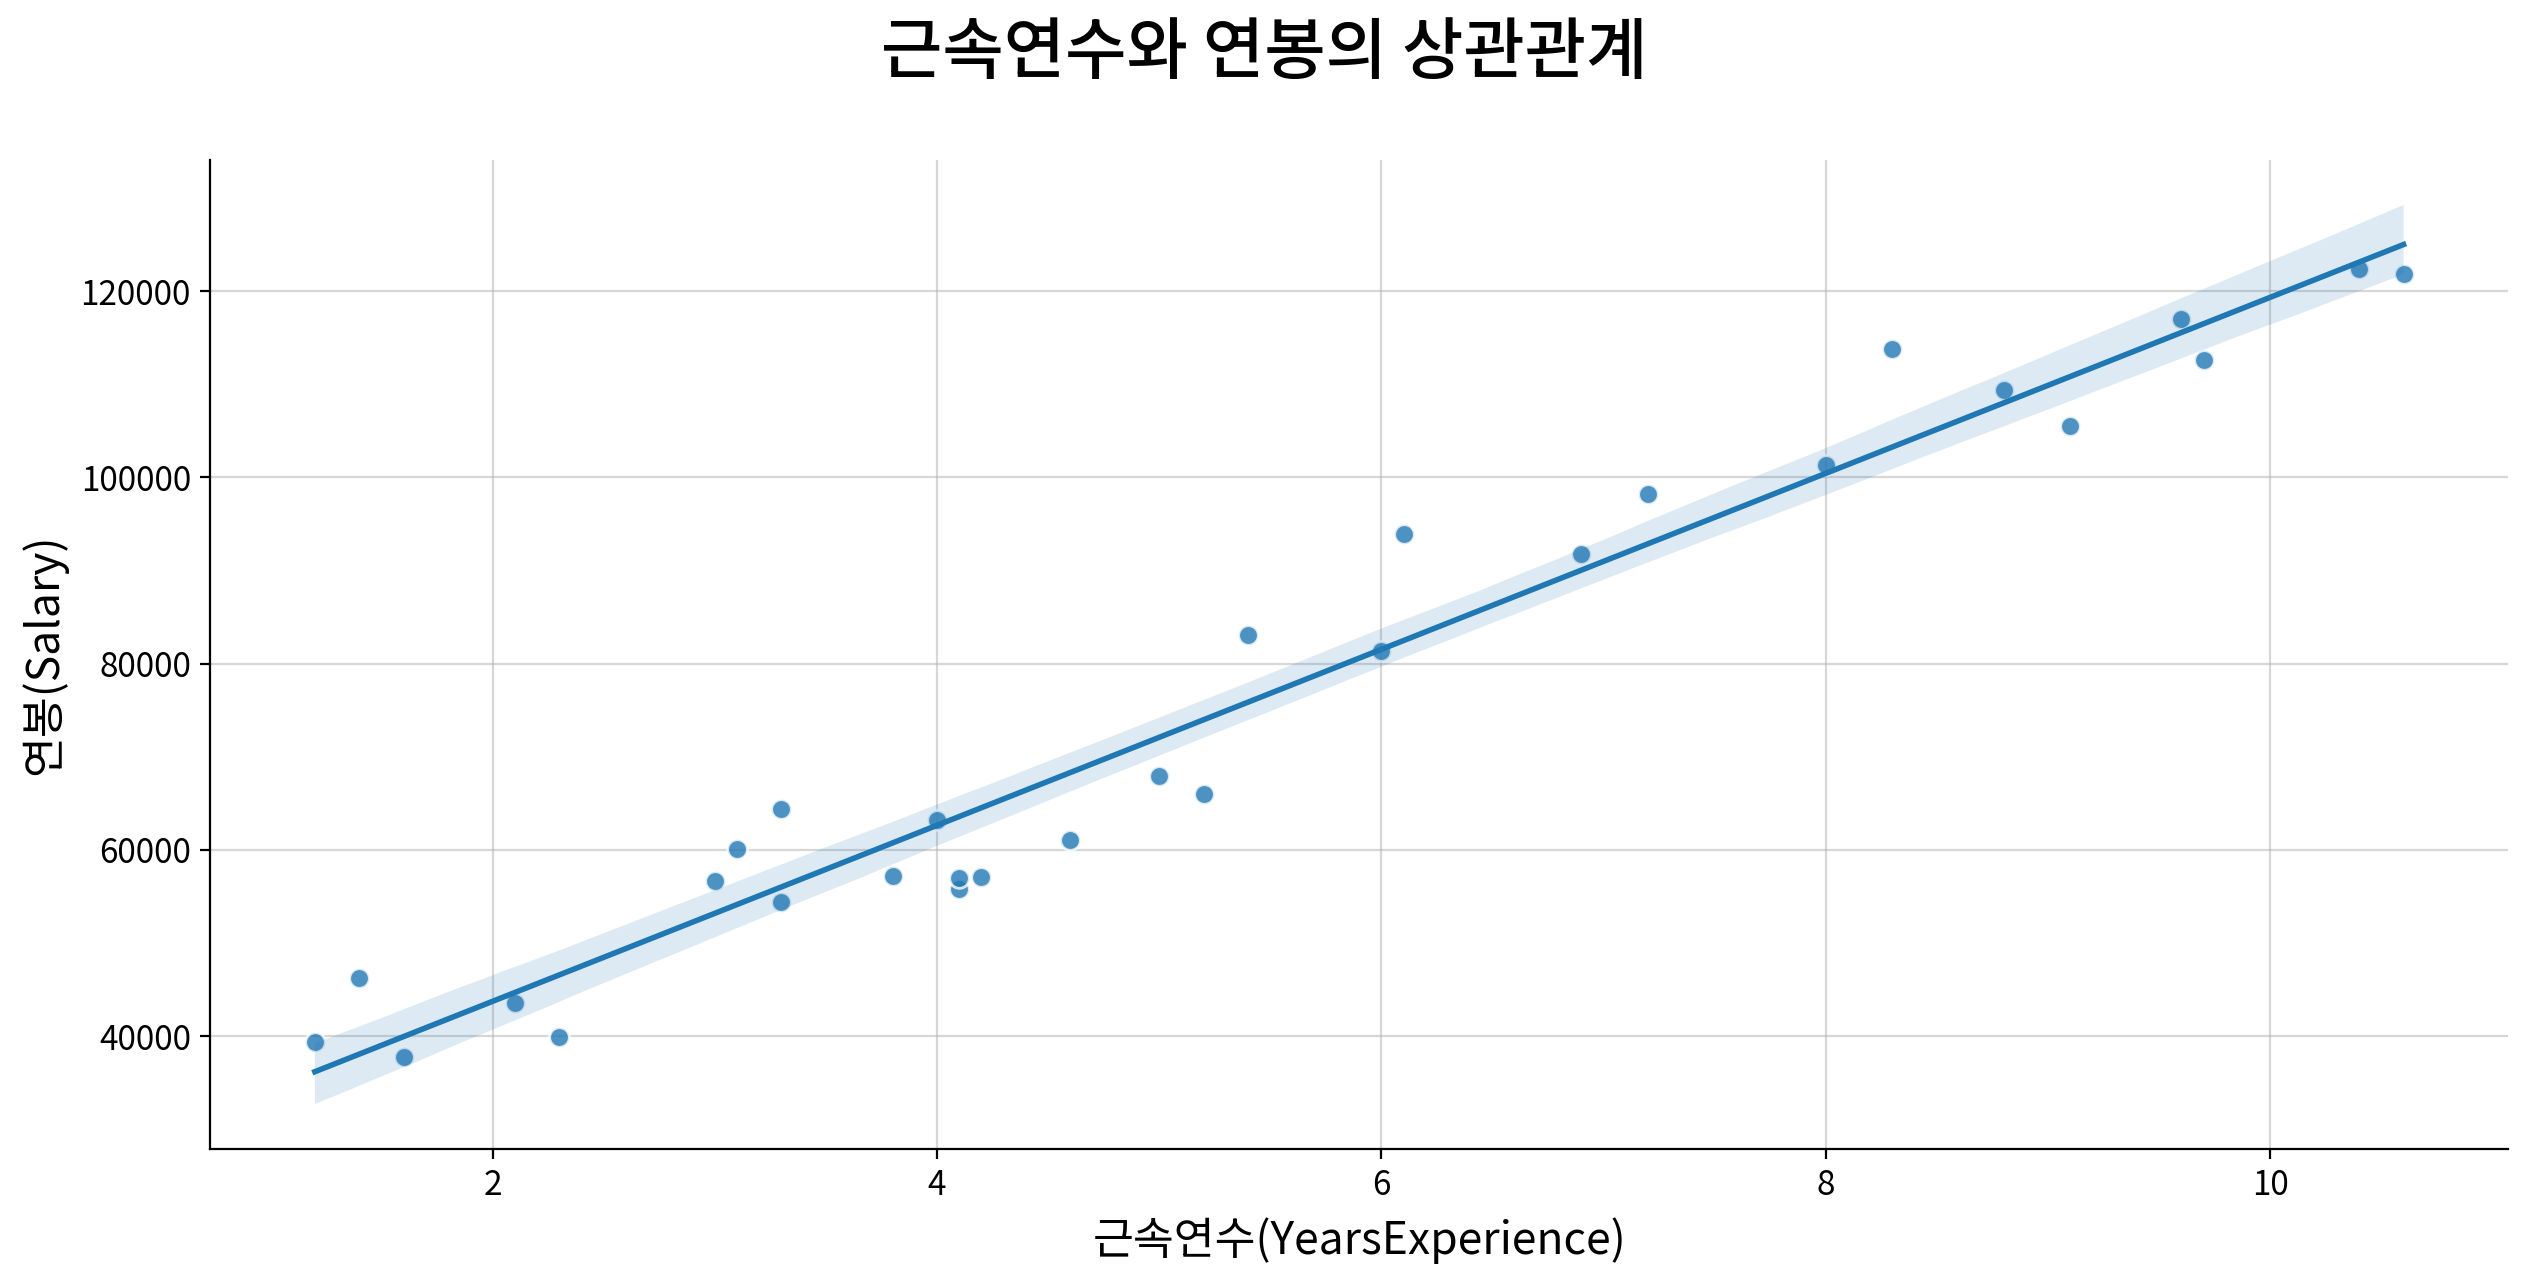

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
YearsExperience,Salary,Spearman,0.957,0.000,Strong,True,True,False,True,False,False


In [14]:
my_stats.correlation(df,x='YearsExperience', y='Salary', plot=True, title='근속연수와 연봉의 상관관계', xlabel='근속연수(YearsExperience)', ylabel='연봉(Salary)')

#### 미션 2. 탐색적 데이터 분석 - 모델설계

- 정규성 검정 결과 정규성 가정을 충족하지 않아, 비모수 상관분석 방법인 Spearman 상관분석을 실시하였다. 분석 결과 p-value가 <0.001로 나타나 두 변수 간 상관관계는 통계적으로 매우 유의하였다. 상관계수 r = 0.957로 나타나 두 변수는 매우 강한 양의 상관관계가 있는 것으로 확인되었다.
- 산점도를 확인한 결과 근속년수가 증가할수록 연봉이 증가하는 선형적 경향이 확인되었다. 따라서 근속년수는 연봉을 예측하는 데 적합한 설명변수로 판단되며, 이후 단순선형회귀분석을 적용할 수 있다.

#### 미션 3.
- y= ax + b(단순선형회귀)
- a = 9449.9623, b= 2.485e+04
- 예측 연봉 = 9449.96 × 근속년수 + 24,850

In [20]:
fit = my_ols.fit_model(df, y='Salary', summary=True)

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           1.14e-20
Time:                        14:59:38   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.485e+04   2306.654     

In [23]:
# 회귀계수 표
vdf = my_ols.report_variables(fit, df)
display(vdf)

# 모형적합도 보고 (로그변환 없음)
display(Markdown(my_ols.report_fitness(fit)))

# 독립변수 보고(로그변환 없음)
display(Markdown(my_ols.report_variables_text(fit)))

,종속변수,독립변수,B,표준오차,β,t,유의확률,공차,VIF
0,Salary,YearsExperience,9449.962,378.755,0.978,24.950,0.000,1.000,1.000


**Note. n = 30. F(1, 28) = 622.51, p < 0.001, R² = 0.957, Adj.R² = 0.955, Durbin_Watson = 1.648**

Salary를 종속변수로, YearsExperience(을)를 독립변수로 한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 28) = 622.51 , p < 0.001, R² = 0.957.

즉, YearsExperience는 Salary의 약 95.7%를 설명하는 것으로 나타났다.

- **YearsExperience**의 회귀계수는 **B = 9449.96**으로 나타났으며, 이는 **Salary**에 유의한 요인임을 의미한다. (**t(28) = 24.95**, **p < .001**) 즉, **YearsExperience가 1 증가**할 때 Salary는 평균적으로 **9449.96 증가**하는 것으로 해석된다.